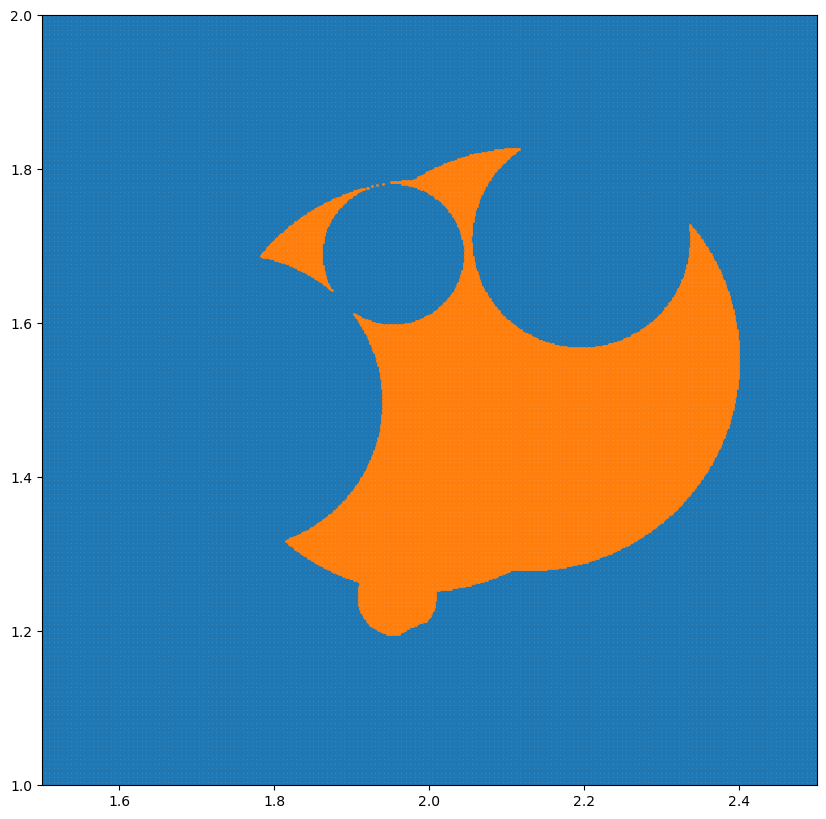

In [ ]:
"""
This code implements a RFM with POU for a 2D Poisson equation. It is modified from the code for solving interface problems using RFM. 
link: https://www.bohrium.com/notebooks/7054790928

Log: Xiaofeng 
12th Aug 2025.  
The code is still under construction. 
It runs but the results are not correct. 
"""

import numpy as np
import itertools
import matplotlib.pyplot as plt
import torch 
import itertools
x_l = 1.5
x_r = 2.5
y_l = 1.0
y_r = 2.0

# definition of round holes (x, y, r, type)
# the holes with type 0 are removed, while the ones with type 1 are filled in
hole = np.array([[1.95759952, 1.24565296, 0.05024437, 0.        ],
       [2.12493956, 1.55343652, 0.27430968, 0.        ],
       [1.98828965, 1.5191257 , 0.26661741, 0.        ],
       [2.19551027, 1.70937434, 0.14129654, 1.        ],
       [2.04655319, 1.06234379, 0.15957007, 1.        ],
       [1.7482689 , 1.49809897, 0.19152733, 1.        ],
       [1.95302039, 1.68997273, 0.09197943, 1.        ]])

hole_remove = hole[hole[:,3]==0.0,:]
hole_fill = hole[hole[:,3]==1.0,:]

def Omega_1(xy):
    yn = None
    for c in range(len(hole_remove)):
        x,y = hole_remove[c,:2]
        r = hole_remove[c,2]
        yn_now = ((xy[:,0]-x)**2 + (xy[:,1]-y)**2) <= r**2
        if yn is None:
            yn = yn_now
        else:
            yn = yn + yn_now
    for c in range(len(hole_fill)):
        x,y = hole_fill[c,:2]
        r = hole_fill[c,2]
        yn_now = ((xy[:,0]-x)**2 + (xy[:,1]-y)**2) > r**2
        yn = yn * yn_now
    return(yn)

def Omega_2(xy):
    return(~Omega_1(xy))

def Gamma(xy):
    yn = None
    for c in range(len(hole)):
        x,y = hole[c,:2]
        r = hole[c,2]
        yn_now = np.abs(((xy[:,0]-x)**2 + (xy[:,1]-y)**2) - r**2) < 1E-10
        if yn is None:
            yn = yn_now
        else:
            yn = yn + yn_now
    return(yn)

def Collocation_Points_Visualization(points):
    points_omega_1 = points[Omega_1(points)]
    points_omega_2 = points[Omega_2(points)]
    plt.figure(figsize=(10, 10))
    plt.xlim([x_l,x_r])
    plt.ylim([y_l,y_r])
    for item in [points_omega_2, points_omega_1]:
        x = item[:,0]
        y = item[:,1]
        plt.scatter(x, y, s=1)
    plt.show()

x_devide = np.linspace(x_l, x_r, 600)
y_devide = np.linspace(y_l, y_r, 600)
points = np.array(list(itertools.product(x_devide, y_devide))).reshape(-1, 2)
Collocation_Points_Visualization(points)

In [74]:
import torch
import torch.nn as nn
from scipy.linalg import lstsq,pinv
import matplotlib.pyplot as plt
import itertools
torch.set_default_dtype(torch.float64)

def set_seed(x): # fix random seed
    np.random.seed(x)
    torch.manual_seed(x)
    torch.cuda.manual_seed_all(x)
    torch.backends.cudnn.deterministic = True

rand_mag = 1.0
def weights_init(m): # random feature (k, b) generation
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.uniform_(m.weight, a = -rand_mag, b = rand_mag)
        nn.init.uniform_(m.bias, a = -rand_mag, b = rand_mag)

class RFM(nn.Module): # random feature function definition \phi_{nj}
    def __init__(self, d, J_n, x_max, x_min, y_max, y_min):
        super(RFM, self).__init__()
        self.d = d
        self.J_n = J_n
        self.a = torch.tensor([2.0/(x_max - x_min),2.0/(y_max - y_min)])
        self.x_c = torch.tensor([(x_max + x_min)/2,(y_max + y_min)/2])
        self.phi = nn.Sequential(nn.Linear(self.d, self.J_n, bias=True),nn.Tanh())

    def forward(self,x):
        x = self.a * (x - self.x_c)
        x = self.phi(x)
        return x

def pre_define(Nx,Ny,J_n): # predefine basis function \phi_{nj} for each partition
    models = []
    for k in range(Nx):
        models_loop = []
        x_min = (x_r - x_l)/Nx * k + x_l
        x_max = (x_r - x_l)/Nx * (k+1) + x_l
        for n in range(Ny):
            y_min = (y_r - y_l)/Ny * n + y_l
            y_max = (y_r - y_l)/Ny * (n+1) + y_l
            # model_omega_1 = RFM(d = 2, J_n = J_n, x_min = x_min, x_max = x_max, y_min = y_min, y_max = y_max)
            # model_omega_1 = model_omega_1.apply(weights_init)
            # model_omega_1 = model_omega_1.double()
            # for param in model_omega_1.parameters():
            #     param.requires_grad = False
            model_omega_2 = RFM(d = 2, J_n = J_n, x_min = x_min, x_max = x_max, y_min = y_min, y_max = y_max)
            model_omega_2 = model_omega_2.apply(weights_init)
            model_omega_2 = model_omega_2.double()
            for param in model_omega_2.parameters():
                param.requires_grad = False
            # models_loop.append([model_omega_1, model_omega_2])
            models_loop.append([ model_omega_2])
            # models.append(model_omega_2)
        models.append(models_loop)
    return(models)

In [114]:
import sympy as sym

# a_1 = 10.0
# a_2 = 1.0

# def anal_u(x,y):
#     u = (10*(x**2 + y**2))*np.cos(2*np.pi*(x+y))
#     if Omega_1(np.array([[x,y]]))[0]:
#         u = (np.exp(x**2 + y**2 - 1.1**2) + 10*(1.1**2) - 1)*np.sin(2*np.pi*(x+y))
#     return u

# def anal_ux(x0,y0):
#     x, y = sym.symbols("x y")
#     u_ = (10*(x**2 + y**2))*sym.cos(2*np.pi*(x+y))
#     if Omega_1(np.array([[x0,y0]]))[0]:
#         u_ = (sym.exp(x**2 + y**2 - 1.1**2) + 10*(1.1**2) - 1)*sym.sin(2*np.pi*(x+y))
#     ux_ = sym.diff(u_, x)
#     ux = sym.lambdify((x, y), ux_, "numpy")
#     return ux(x0,y0)

# def anal_uy(x0,y0):
#     x, y = sym.symbols("x y")
#     u_ = (10*(x**2 + y**2))*sym.cos(2*np.pi*(x+y))
#     if Omega_1(np.array([[x0,y0]]))[0]:
#         u_ = (sym.exp(x**2 + y**2 - 1.1**2) + 10*(1.1**2) - 1)*sym.sin(2*np.pi*(x+y))
#     uy_ = sym.diff(u_, y)
#     uy = sym.lambdify((x, y), uy_, "numpy")
#     return uy(x0,y0)

# def anal_h_1(x,y):
#     u2 = (10*(x**2 + y**2))*np.cos(2*np.pi*(x+y))
#     u1 = (np.exp(x**2 + y**2 - 1.1**2) + 10*(1.1**2) - 1)*np.sin(2*np.pi*(x+y))
#     return(u1 - u2)

# def anal_h_2(x0,y0,nx,ny):
#     x, y = sym.symbols("x y")
#     u_2 = (10*(x**2 + y**2))*sym.cos(2*np.pi*(x+y))
#     u_1 = (sym.exp(x**2 + y**2 - 1.1**2) + 10*(1.1**2) - 1)*sym.sin(2*np.pi*(x+y))
#     ux_1 = sym.diff(u_1, x)
#     ux_2 = sym.diff(u_2, x)
#     uy_1 = sym.diff(u_1, y)
#     uy_2 = sym.diff(u_2, y)
#     h_2 = sym.lambdify((x, y), a_1 * (ux_1*nx + uy_1*ny) - a_2 * (ux_2*nx + uy_2*ny), "numpy")
#     return h_2(x0,y0)

# def anal_a(x,y):
#     a = a_2
#     if Omega_1(np.array([[x,y]]))[0]:
#         a = a_1
#     return a

# def anal_ax(x,y):
#     ax = 0
#     return ax

# def anal_ay(x,y):
#     ay = 0
#     return ay

# def anal_f(x0,y0):
#     x, y = sym.symbols("x y")
#     u_ = (10*(x**2 + y**2))*sym.cos(2*np.pi*(x+y))
#     if Omega_1(np.array([[x0,y0]]))[0]:
#         u_ = (sym.exp(x**2 + y**2 - 1.1**2) + 10*(1.1**2) - 1)*sym.sin(2*np.pi*(x+y))
#     ux = sym.diff(u_, x)
#     uy = sym.diff(u_, y)
#     uxx = sym.diff(ux, x)
#     uyy = sym.diff(uy, y)
#     f_ = - a_2 * (uxx + uyy)
#     if Omega_1(np.array([[x0,y0]]))[0]:
#         f_ = - a_1 * (uxx + uyy)
#     f = sym.lambdify((x, y), f_, "numpy")
#     return f(x0,y0)

# vanal_a = np.vectorize(anal_a)
# vanal_ax = np.vectorize(anal_ax)
# vanal_ay = np.vectorize(anal_ay)
# vanal_u = np.vectorize(anal_u)
# vanal_ux = np.vectorize(anal_ux)
# vanal_uy = np.vectorize(anal_uy)
# vanal_f = np.vectorize(anal_f)


## new definitions for -\Laplacian + u  = f in \Omega, u = g on \partial \Omega 

m1 = 1 
m2 = 1 
lamb = 1 
def u(x,y): 
    return np.sin(m1 * np.pi * x) +  np.cos(m2 * np.pi * y)

def u_x(x,y):
    return m1 * np.pi * np.cos(m1 * np.pi * x)
def u_y(x,y):
    return -m2 * np.pi * np.sin(m2 * np.pi * y)
def laplacian_u(x,y): #
    return - m1**2 * np.pi**2 * np.sin(m1 * np.pi * x) - m2**2 * np.cos(m2 * np.pi * y)

def F(x,y):
    return(- laplacian_u(x,y)  + lamb * u(x,y)) # change 


## main function 

To-do: 
0. pre_define function: defines the models 
1. assemble matrix 
2. test model accuracy

In [115]:
# Assembling the matrix A,f in linear system 'Au=f'
def assemble_matrix(models,points,Nx,Ny,J_n,Qx,Qy):
    ''' following are the assembly of the PDE terms and smoothness terms within region \Omega_{1} '''
    # The part has been deleted because we do not solve an interface problem in region \Omega_{1} 
    
    ''' following are the assembly of the PDE terms, boundary terms and smoothness terms within region \Omega_{2} '''
    A_1 = None
    A_2 = np.zeros([Nx*Qx,Nx*Ny*J_n])
    f_2 = np.zeros([Nx*Qx,1])
    A_3 = np.zeros([Nx*Qx,Nx*Ny*J_n])
    f_3 = np.zeros([Nx*Qx,1])
    A_4 = np.zeros([Ny*Qy,Nx*Ny*J_n])
    f_4 = np.zeros([Ny*Qy,1])
    A_5 = np.zeros([Ny*Qy,Nx*Ny*J_n])
    f_5 = np.zeros([Ny*Qy,1])
    A_y_c = np.zeros([Nx*Qx*(Ny-1),Nx*Ny*J_n])
    f_y_c = np.zeros([Nx*Qx*(Ny-1),1])
    A_x_c = np.zeros([Ny*Qy*(Nx-1),Nx*Ny*J_n])
    f_x_c = np.zeros([Ny*Qy*(Nx-1),1])
    A_y_c_1 = np.zeros([Nx*Qx*(Ny-1),Nx*Ny*J_n])
    f_y_c_1 = np.zeros([Nx*Qx*(Ny-1),1])
    A_x_c_1 = np.zeros([Ny*Qy*(Nx-1),Nx*Ny*J_n])
    f_x_c_1 = np.zeros([Ny*Qy*(Nx-1),1])
    
    k = 0
    n = 0
    for k in range(Nx):
        for n in range(Ny):
            in_ = points[k][n].detach().numpy()
            # in_index = Omega_2(in_[:Qx,:Qy,:].reshape((-1,2))) 
            in_index = np.ones(Qx*Qy, dtype=bool)
            out = models[k][n][0](points[k][n]) # points dimension * J_n 
            values = out.detach().numpy()
            J_n_begin = k*Ny*J_n + n*J_n
            
            # boundary terms within region \Omega_{2} # no need to change 
            if n == 0: # y =y_min 
                A_2[k*Qx : k*Qx+Qx, J_n_begin : J_n_begin + J_n] = values[:Qx,0,:]
                f_2[k*Qx : k*Qx+Qx,:] = \
                    u(in_[:Qx,0,0],in_[:Qx,0,1]).reshape((Qx,1))
            if n == Ny-1: #y = y_max
                A_3[k*Qx : k*Qx+Qx, J_n_begin : J_n_begin + J_n] = values[:Qx,-1,:]
                f_3[k*Qx : k*Qx+Qx,:] =\
                    u(in_[:Qx,-1,0],in_[:Qx,-1,1]).reshape((Qx,1))
            if k == 0: # x = x_min 
                A_4[n*Qy : n*Qy+Qy, J_n_begin : J_n_begin + J_n] = values[0,:Qy,:]
                f_4[n*Qy : n*Qy+Qy,:] =\
                    u(in_[0,:Qy,0],in_[0,:Qy,1]).reshape((Qy,1))
            if k == Nx-1: # x = x_max 
                A_5[n*Qy : n*Qy+Qy, J_n_begin : J_n_begin + J_n] = values[-1,:Qy,:]
                f_5[n*Qy : n*Qy+Qy,:] = \
                    u(in_[-1,:Qy,0],in_[-1,:Qy,1]).reshape((Qy,1))
            
            grads = []
            grads_2_xx = []
            grads_2_yy = []
            for i in range(J_n): # compute u_x, u_y, u_xx, u_yy 
                g_1 = torch.autograd.grad(outputs=out[:,:,i], inputs=points[k][n],
                                      grad_outputs=torch.ones_like(out[:,:,i]),
                                      create_graph = True, retain_graph = True)[0]
                grads.append(g_1.squeeze().detach().numpy()) 
                
                g_2_x = torch.autograd.grad(outputs=g_1[:,:,0], inputs=points[k][n],
                                  grad_outputs=torch.ones_like(out[:,:,i]),
                                  create_graph = False, retain_graph = True)[0]
                g_2_y = torch.autograd.grad(outputs=g_1[:,:,1], inputs=points[k][n],
                                  grad_outputs=torch.ones_like(out[:,:,i]),
                                  create_graph = False, retain_graph = True)[0]
                grads_2_xx.append(g_2_x[:,:,0].squeeze().detach().numpy())
                grads_2_yy.append(g_2_y[:,:,1].squeeze().detach().numpy())
                
            grads = np.array(grads).swapaxes(0,3)
            grads_2_xx = np.array(grads_2_xx)
            grads_2_xx = grads_2_xx[:,:Qx,:Qy]
            grads_2_xx = grads_2_xx.transpose(1,2,0).reshape(-1,J_n)
            grads_2_yy = np.array(grads_2_yy)
            grads_2_yy = grads_2_yy[:,:Qx,:Qy]
            grads_2_yy = grads_2_yy.transpose(1,2,0).reshape(-1,J_n)
            ux = grads[0,:Qx,:Qy,:].reshape(-1,J_n)[in_index,:] # points * J_n
            uy = grads[0,:Qx,:Qy,:].reshape(-1,J_n)[in_index,:] # points * J_n
            uxx = grads_2_xx[in_index,:] # points * J_n
            uyy = grads_2_yy[in_index,:] # points * J_n
            
            # PDE terms within region \Omega_{2}
            f_in = in_[:Qx,:Qy,:].reshape((-1,2))[in_index]
            if len(f_in) > 0:
                A1 = np.zeros((sum(in_index),Nx*Ny*J_n))
                # A1[:, J_n_begin : J_n_begin + J_n] = -(ax*ux + ay*uy + a*(uxx + uyy)) 
                A1[:, J_n_begin : J_n_begin + J_n] =  uxx + uyy  + lamb * values[:Qx,:Qy].reshape(-1,J_n)
                f1 = F(f_in[:,0],f_in[:,1]).reshape(-1,1) # rhs 
                if A_1 is None:
                    A_1 = A1
                    f_1 = f1
                else:
                    A_1 = np.concatenate((A_1,A1),axis = 0)
                    f_1 = np.concatenate((f_1,f1),axis = 0)

            # smoothness terms within region \Omega_{2}
            # x_axis continuity
            if Nx > 1:
                x_axis_begin = n*(Nx-1)*Qy + k*Qy
                if k == 0:
                    A_x_c[x_axis_begin : x_axis_begin + Qy, J_n_begin : J_n_begin + J_n] = values[-1,:Qy,:]
                    A_x_c_1[x_axis_begin : x_axis_begin + Qy, J_n_begin : J_n_begin + J_n] = grads[0,-1,:Qy,:]
                elif k == Nx-1:
                    A_x_c[x_axis_begin - Qy : x_axis_begin, J_n_begin : J_n_begin + J_n] = -values[0,:Qy,:]
                    A_x_c_1[x_axis_begin - Qy : x_axis_begin, J_n_begin : J_n_begin + J_n] = -grads[0,0,:Qy,:]
                else:
                    A_x_c[x_axis_begin : x_axis_begin + Qy, J_n_begin : J_n_begin + J_n] = values[-1,:Qy,:]
                    A_x_c[x_axis_begin - Qy : x_axis_begin, J_n_begin : J_n_begin + J_n] = -values[0,:Qy,:]
                    A_x_c_1[x_axis_begin : x_axis_begin + Qy, J_n_begin : J_n_begin + J_n] = grads[0,-1,:Qy,:]
                    A_x_c_1[x_axis_begin - Qy : x_axis_begin, J_n_begin : J_n_begin + J_n] = -grads[0,0,:Qy,:]
            
            # y_axis continuity
            if Ny > 1:
                y_axis_begin = k*(Ny-1)*Qx + n*Qx 
                if n == 0:
                    A_y_c[y_axis_begin : y_axis_begin + Qx, J_n_begin : J_n_begin + J_n] = values[:Qx,-1,:]
                    A_y_c_1[y_axis_begin : y_axis_begin + Qx, J_n_begin : J_n_begin + J_n] = grads[1,:Qx,-1,:]
                elif n == Ny-1:
                    A_y_c[y_axis_begin - Qx : y_axis_begin, J_n_begin : J_n_begin + J_n] = -values[:Qx,0,:]
                    A_y_c_1[y_axis_begin - Qx : y_axis_begin, J_n_begin : J_n_begin + J_n] = -grads[1,:Qx,0,:]
                else:
                    A_y_c[y_axis_begin : y_axis_begin + Qx, J_n_begin : J_n_begin + J_n] = values[:Qx,-1,:]
                    A_y_c[y_axis_begin - Qx : y_axis_begin, J_n_begin : J_n_begin + J_n] = -values[:Qx,0,:]
                    A_y_c_1[y_axis_begin : y_axis_begin + Qx, J_n_begin : J_n_begin + J_n] = grads[1,:Qx,-1,:]
                    A_y_c_1[y_axis_begin - Qx : y_axis_begin, J_n_begin : J_n_begin + J_n] = -grads[1,:Qx,0,:]
    A_continuity = np.concatenate((A_y_c,A_y_c_1,A_x_c,A_x_c_1),axis=0)
    f_continuity = np.concatenate((f_y_c,f_y_c_1,f_x_c,f_x_c_1),axis=0)
    A_1 = np.array(A_1,dtype=np.float64)
    f_1 = np.array(f_1,dtype=np.float64)
    A_omega_2 = np.concatenate((A_1,A_2,A_3,A_4,A_5,A_continuity),axis=0)
    f_omega_2 = np.concatenate((f_1,f_2,f_3,f_4,f_5,f_continuity),axis=0)
    A_omega_2 = np.concatenate((A_1,A_2,A_3,A_4,A_5),axis=0)
    f_omega_2 = np.concatenate((f_1,f_2,f_3,f_4,f_5),axis=0)
    max_value = 10.0
    for i in range(len(A_omega_2)):
        ratio = max_value/np.abs(A_omega_2[i,:]).max()
        A_omega_2[i,:] = A_omega_2[i,:]*ratio
        f_omega_2[i] = f_omega_2[i]*ratio
    
    ''' following is the assembly of the overall linear system '''
    # A_omega_1 = np.concatenate((A_omega_1,np.zeros(A_omega_1.shape)),axis=1)
    # A_omega_2 = np.concatenate((np.zeros(A_omega_2.shape),A_omega_2),axis=1)
    # A = np.concatenate((A_omega_1,A_omega_2,B_c_d,B_c_n),axis=0)
    # f = np.concatenate((f_omega_1,f_omega_2,p_c_d,p_c_n),axis=0)
    return(A_omega_2 ,f_omega_2 )

## how to compute errors for the random feature model? 
1. Evaluate in each subdomain for each model models[k][n][0] # (k,n) specifies the subdomain, 0 specifies the model, for this problem only one neural network in each subdomain.
2. generate points in each subdomain: [x_min, x_max] \times [y_min, y_max] and evaluate numerical solution and true solution values on there points in each subdomain 
    - here 
3. Use a list to store function values in each subdomain 
    -  numerical_values_u = []; numerical_grad_x_values = []; numerical_grad_y_values = []; true_values_u = []; true_values_ux = []; true_values_uy = []
4. 

In [116]:
import math
def test(models,Nx,Ny,J_n,Qx,Qy,w,plot):
    
    ''' following are the true value, numerical value and mask calculation on region \Omega '''
    numerical_values_u = []
    numerical_grad_x_values = []
    numerical_grad_y_values = []
    true_values_u = []
    true_values_ux = []
    true_values_uy = []
    
    point = []
    mask = []
    test_Qx = 2*Qx
    test_Qt = 2*Qy
    for k in range(Nx):
        numerical_value_u_x = []
        numerical_grad_x_value_x = []
        numerical_grad_y_value_x = []
        true_value_u_x = []
        true_value_ux_x = []
        true_value_uy_x = []
        point_x = []
        mask_x = []
        for n in range(Ny):
            x_min = (x_r - x_l)/Nx * k + x_l
            x_max = (x_r - x_l)/Nx * (k+1) + x_l
            y_min = (y_r - y_l)/Ny * n + y_l
            y_max = (y_r - y_l)/Ny * (n+1) + y_l
            x_devide = np.linspace(x_min, x_max, test_Qx + 1)[:test_Qx]
            t_devide = np.linspace(y_min, y_max, test_Qt + 1)[:test_Qt]
            grid = np.array(list(itertools.product(x_devide,t_devide)))
            test_point = torch.tensor(grid,requires_grad=True)
            print("test point size", test_point.size())
            point_x.append(test_point.detach().numpy().reshape(test_Qx,test_Qt,2))
            out_u = models[k][n][0](test_point)
            print("nn output size: ", out_u.size())
            u_grads = []
            for i in range(J_n):
                u_xy = torch.autograd.grad(outputs=out_u[:,i], inputs=test_point,
                                      grad_outputs=torch.ones_like(out_u[:,i]),
                                      create_graph = True, retain_graph = True)[0]
                u_grads.append(u_xy.squeeze().detach().numpy())
            
            u_grads = np.array(u_grads).swapaxes(0,2)
            numerical_grad_x = np.dot(u_grads[0,:,:], w[k*Ny*J_n + n*J_n : k*Ny*J_n + n*J_n + J_n,:]).reshape(test_Qx,test_Qt)
            numerical_grad_y = np.dot(u_grads[1,:,:], w[k*Ny*J_n + n*J_n : k*Ny*J_n + n*J_n + J_n,:]).reshape(test_Qx,test_Qt)
            value_u = out_u.detach().numpy()
            # mask_x.append(Omega_1(grid).reshape(test_Qx,test_Qt))
            mask_x.append(np.ones( (test_Qx,test_Qt), dtype=bool) ) ## 
            # print(mask_x[0].shape)
            # print(mask_x[0])
            true_value_u = u(grid[:,0],grid[:,1]).reshape(test_Qx,test_Qt) 
            true_value_ux = u_x(grid[:,0],grid[:,1]).reshape(test_Qx,test_Qt) 
            true_value_uy = u_y(grid[:,0],grid[:,1]).reshape(test_Qx,test_Qt)  
            numerical_value_u = np.dot(value_u, w[k*Ny*J_n + n*J_n : k*Ny*J_n + n*J_n + J_n,:]).reshape(test_Qx,test_Qt)
            true_value_u_x.append(true_value_u)
            true_value_ux_x.append(true_value_ux)
            true_value_uy_x.append(true_value_uy)
            numerical_value_u_x.append(numerical_value_u)
            numerical_grad_x_value_x.append(numerical_grad_x)
            numerical_grad_y_value_x.append(numerical_grad_y)
        mask_x = np.concatenate(mask_x, axis=1)
        mask.append(mask_x)
        numerical_value_u_x = np.concatenate(numerical_value_u_x, axis=1)
        numerical_values_u.append(numerical_value_u_x)
        numerical_grad_x_value_x = np.concatenate(numerical_grad_x_value_x, axis=1)
        numerical_grad_y_value_x = np.concatenate(numerical_grad_y_value_x, axis=1)
        numerical_grad_x_values.append(numerical_grad_x_value_x)
        numerical_grad_y_values.append(numerical_grad_y_value_x)
        true_value_u_x = np.concatenate(true_value_u_x, axis=1)
        true_values_u.append(true_value_u_x)
        true_value_ux_x = np.concatenate(true_value_ux_x, axis=1)
        true_values_ux.append(true_value_ux_x)
        true_value_uy_x = np.concatenate(true_value_uy_x, axis=1)
        true_values_uy.append(true_value_uy_x)
        point_x = np.concatenate(point_x, axis=1)
        point.append(point_x)
    mask = np.concatenate(mask, axis=0)
    numerical_values_u_plus = np.concatenate(numerical_values_u, axis=0)*mask.astype(float)
    numerical_grad_x_values_plus = np.concatenate(numerical_grad_x_values, axis=0)*mask.astype(float)
    numerical_grad_y_values_plus = np.concatenate(numerical_grad_y_values, axis=0)*mask.astype(float)
    true_values_u = np.concatenate(true_values_u, axis=0)
    true_values_ux = np.concatenate(true_values_ux, axis=0)
    true_values_uy = np.concatenate(true_values_uy, axis=0)
    point = np.concatenate(point, axis=0)
     
    ''' following is the L_{2} relative error calculation '''
    epsilon_u = np.abs(numerical_values_u_plus - true_values_u)
    epsilon_ux = np.abs(numerical_grad_x_values_plus - true_values_ux)
    epsilon_uy = np.abs(numerical_grad_y_values_plus - true_values_uy)
    e_u = epsilon_u.reshape((-1,1))
    e_ux = epsilon_ux.reshape((-1,1))
    e_uy = epsilon_uy.reshape((-1,1))
    value_u = true_values_u.reshape((-1,1))
    value_ux = true_values_ux.reshape((-1,1))
    value_uy = true_values_uy.reshape((-1,1))
    
    r = [math.sqrt(sum(e_u*e_u)/len(e_u))/math.sqrt(sum(value_u*value_u)/len(value_u)),
         math.sqrt(sum(e_ux*e_ux)/len(e_ux))/math.sqrt(sum(value_ux*value_ux)/len(value_ux)),
         math.sqrt(sum(e_uy*e_uy)/len(e_uy))/math.sqrt(sum(value_uy*value_uy)/len(value_uy))]
    
    print("L2 relative error for u: %.2e"%(r[0]))
    print("L2 relative error for ux: %.2e"%(r[1]))
    print("L2 relative error for uy: %.2e \n"%(r[2]))
    return(r)
    
    

In [117]:
from scipy.linalg import lstsq
def main(Nx,Ny,J_n,Qx,Qy,plot=False):
    # predifine RFM models
    models = pre_define(Nx,Ny,J_n)
    
    # collocation points sampling
    points = []
    for k in range(Nx):
        points_loop = []
        x_min = (x_r - x_l)/Nx * k + x_l
        x_max = (x_r - x_l)/Nx * (k+1) + x_l
        x_devide = np.linspace(x_min, x_max, Qx + 1)
        for n in range(Ny):
            y_min = (y_r - y_l)/Ny * n + y_l
            y_max = (y_r - y_l)/Ny * (n+1) + y_l
            y_devide = np.linspace(y_min, y_max, Qy + 1)
            grid = np.array(list(itertools.product(x_devide,y_devide))).reshape(Qx+1,Qy+1,2)
            points_loop.append(torch.tensor(grid,requires_grad=True))
        points.append(points_loop)
    
    # matrix define (Aw=b)
    A,f = assemble_matrix(models,points,Nx,Ny,J_n,Qx,Qy)
    
    # rescaling strategy
    c = 100.0
    for i in range(len(A)):
        ratio = c/A[i,:].max()
        A[i,:] = A[i,:]*ratio
        f[i] = f[i]*ratio
    
    # solve
    w = lstsq(A,f)[0] # shape: (total num feature, 1)

    # test
    return(test(models,Nx,Ny,J_n,Qx,Qy,w,plot))

RFM parameter settings: M_p = 4, Q = 100, J_n = 80
test point size torch.Size([400, 2])
nn output size:  torch.Size([400, 80])
test point size torch.Size([400, 2])
nn output size:  torch.Size([400, 80])
test point size torch.Size([400, 2])
nn output size:  torch.Size([400, 80])
test point size torch.Size([400, 2])
nn output size:  torch.Size([400, 80])


/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_1888/3749317218.py:99: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  r = [math.sqrt(sum(e_u*e_u)/len(e_u))/math.sqrt(sum(value_u*value_u)/len(value_u)),
/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_1888/3749317218.py:100: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  math.sqrt(sum(e_ux*e_ux)/len(e_ux))/math.sqrt(sum(value_ux*value_ux)/len(value_ux)),
/var/folders/45/p1_q2drx75983lk7ph_1gx6mhpr5_w/T/ipykernel_1888/3749317218.py:101: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single

L2 relative error for u: 1.09e+02
L2 relative error for ux: 1.74e+02
L2 relative error for uy: 1.75e+02 

RFM parameter settings: M_p = 4, Q = 400, J_n = 80
test point size torch.Size([1600, 2])
nn output size:  torch.Size([1600, 80])
test point size torch.Size([1600, 2])
nn output size:  torch.Size([1600, 80])
test point size torch.Size([1600, 2])
nn output size:  torch.Size([1600, 80])
test point size torch.Size([1600, 2])
nn output size:  torch.Size([1600, 80])
L2 relative error for u: 2.41e+02
L2 relative error for ux: 3.82e+02
L2 relative error for uy: 3.78e+02 



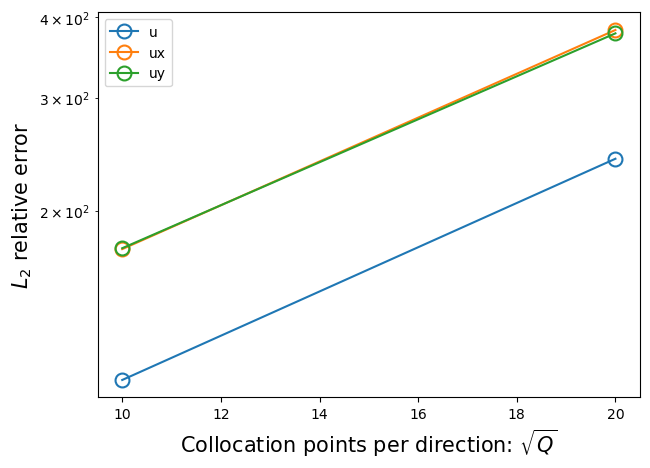

In [119]:
if __name__ == '__main__':
    # set_seed(100)
    error = []
    for M_p in [4]:
        Q_list = [10,20] 
        for Q in Q_list:  
            for J_n in [80]:
                Nx = int(np.sqrt(M_p))
                Ny = int(np.sqrt(M_p))
                Qx = Q
                Qy = Q
                print("RFM parameter settings: M_p = %s, Q = %s, J_n = %s"%(M_p,Qx*Qy,J_n))
                error.append(main(Nx,Ny,J_n,Qx,Qy,True))
    error = np.array(error)
    plt.figure(figsize=[7, 5])
    plt.tick_params(labelsize=10)
    font2 = {
    'weight' : 'normal',
    'size'   : 15,
    }
    plt.xlabel('Collocation points per direction: $\sqrt{Q}$',font2)
    plt.ylabel('$L_2$ relative error',font2)
    plt.yscale('log')
    Label = ['u','ux','uy']
    for i in range(3):
        plt.plot(np.array(Q_list), error[:,i], \
                 lw=1.5, ls='-', clip_on=False,\
                 marker='o', markersize=10, \
                 label = Label[i],\
                 markerfacecolor='none',\
                 markeredgewidth=1.5)
    plt.legend()
    plt.show()

## playground 

In [4]:
# collocation points sampling
Nx = 2 
Ny = 2 
Qx = 5 
Qy = 5 
J_n = 25 
# models = pre_define(Nx,Ny,J_n) 
x_l, x_r = 0, 1 
y_l, y_r = 0, 1 
points = []
for k in range(Nx):
    points_loop = []
    x_min = (x_r - x_l)/Nx * k + x_l
    x_max = (x_r - x_l)/Nx * (k+1) + x_l
    x_devide = np.linspace(x_min, x_max, Qx + 1)
    for n in range(Ny):
        y_min = (y_r - y_l)/Ny * n + y_l
        y_max = (y_r - y_l)/Ny * (n+1) + y_l
        y_devide = np.linspace(y_min, y_max, Qy + 1)
        grid = np.array(list(itertools.product(x_devide,y_devide))).reshape(Qx+1,Qy+1,2)
        points_loop.append(torch.tensor(grid,requires_grad=True))
    points.append(points_loop)

print(points[0][0])

tensor([[[0.0000, 0.0000],
         [0.0000, 0.1000],
         [0.0000, 0.2000],
         [0.0000, 0.3000],
         [0.0000, 0.4000],
         [0.0000, 0.5000]],

        [[0.1000, 0.0000],
         [0.1000, 0.1000],
         [0.1000, 0.2000],
         [0.1000, 0.3000],
         [0.1000, 0.4000],
         [0.1000, 0.5000]],

        [[0.2000, 0.0000],
         [0.2000, 0.1000],
         [0.2000, 0.2000],
         [0.2000, 0.3000],
         [0.2000, 0.4000],
         [0.2000, 0.5000]],

        [[0.3000, 0.0000],
         [0.3000, 0.1000],
         [0.3000, 0.2000],
         [0.3000, 0.3000],
         [0.3000, 0.4000],
         [0.3000, 0.5000]],

        [[0.4000, 0.0000],
         [0.4000, 0.1000],
         [0.4000, 0.2000],
         [0.4000, 0.3000],
         [0.4000, 0.4000],
         [0.4000, 0.5000]],

        [[0.5000, 0.0000],
         [0.5000, 0.1000],
         [0.5000, 0.2000],
         [0.5000, 0.3000],
         [0.5000, 0.4000],
         [0.5000, 0.5000]]], dtype=torch.floa

### Structure of points
    index_i, index_j, coordinates 
    column-major ordering starting from the bottom-left point

    3 by 3 grid example: 
    (0,0) -> (0,1) -> (0,2) -> (1,0) -> (1,1) -> (1,2) -> ...-> (2,2)

In [ ]:
## index_i, index_j, coordinates 
##
#ith row points[k][n][:Qx,i-1]
print(points[0][0][:Qx,0]) # first row 

#jth column points[k][n][j-1,:Qy] 
print(points[0][0][0,:Qy]) # first column

tensor([[0.0000, 0.0000],
        [0.1000, 0.0000],
        [0.2000, 0.0000],
        [0.3000, 0.0000],
        [0.4000, 0.0000]], dtype=torch.float64, grad_fn=<SelectBackward0>)
tensor([[0.0000, 0.0000],
        [0.0000, 0.1000],
        [0.0000, 0.2000],
        [0.0000, 0.3000],
        [0.0000, 0.4000]], dtype=torch.float64, grad_fn=<SliceBackward0>)


In [52]:
models[0][0][0](points[0][0].view(-1,2) )



tensor([[ 8.6478e-03,  6.4727e-01,  6.8815e-01, -3.3374e-01,  3.3277e-01,
          8.5060e-01,  4.4626e-01, -6.7576e-01, -7.4095e-01, -7.8530e-01,
         -2.4477e-01, -7.6500e-01, -1.8192e-01,  8.9286e-01, -5.4888e-01,
          7.2555e-01,  9.6083e-01,  9.2534e-01,  8.9677e-01, -1.5843e-01,
          3.6722e-01,  7.4860e-01, -3.2438e-01,  9.0264e-01,  7.2061e-02],
        [-1.5972e-02,  6.5856e-01,  6.7477e-01, -2.2013e-01,  1.0165e-01,
          7.6538e-01,  1.2205e-01, -6.6968e-01, -7.9818e-01, -6.7398e-01,
          1.4996e-02, -8.3250e-01, -6.6450e-02,  7.9375e-01, -3.7617e-01,
          6.6714e-01,  9.3025e-01,  8.4313e-01,  8.8238e-01, -3.6361e-01,
          1.7170e-01,  6.6463e-01, -5.8627e-01,  8.7531e-01,  3.4971e-01],
        [-4.0572e-02,  6.6957e-01,  6.6093e-01, -1.0023e-01, -1.4100e-01,
          6.4098e-01, -2.3049e-01, -6.6350e-01, -8.4390e-01, -5.2044e-01,
          2.7275e-01, -8.8190e-01,  5.0825e-02,  6.2132e-01, -1.7265e-01,
          5.9919e-01,  8.7729e-01,  

In [ ]:
k= 0 
n = 0
in_ = points[k][n].detach().numpy()
print(in_.shape)
in_index = np.ones(Qx*Qy, dtype=bool)
print(in_index)



(6, 6, 2)
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True]
